In [ ]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

# Чтобы графики показывались внутри ноутбука
%matplotlib inline

# Папки для данных и картинок
DATA_DIR = Path("data")
IMG_DIR = Path("img")
DATA_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(exist_ok=True)

# Параметры трёх окружностей из условия A1:
#   центр (1,1), радиус 1
#   центр (1.5, 2), радиус sqrt(5)/2
#   центр (2, 1.5), радиус sqrt(5)/2
circles = [
    (1.0, 1.0, 1.0),
    (1.5, 2.0, math.sqrt(5) / 2.0),
    (2.0, 1.5, math.sqrt(5) / 2.0),
]

# Точная площадь пересечения из условия:
# S = 0.25 * pi + 1.25 * arcsin(0.8) - 1
S_exact = 0.25 * math.pi + 1.25 * math.asin(0.8) - 1.0
S_exact


0.9445171858994637

In [ ]:
try:
    print("Геометрия разбиения на T, C1, C2, C3:")
    display(Image(filename=str(IMG_DIR / "three_circles_geometry.png")))
except FileNotFoundError:
    print("three_circles_geometry.png не найден, пропускаю.")

try:
    print("Широкая и узкая прямоугольные области:")
    display(Image(filename=str(IMG_DIR / "three_circles_rectangles.png")))
except FileNotFoundError:
    print("three_circles_rectangles.png не найден, пропускаю.")


Геометрия разбиения на T, C1, C2, C3:
three_circles_geometry.png не найден, пропускаю.
Широкая и узкая прямоугольные области:
three_circles_rectangles.png не найден, пропускаю.


In [ ]:
def make_wide_rect(circles):
    """
    Широкая область: bounding box по всем трём окружностям.
    Возвращает словарь с границами и площадью.
    """
    xs_min = []
    xs_max = []
    ys_min = []
    ys_max = []

    for xc, yc, r in circles:
        xs_min.append(xc - r)
        xs_max.append(xc + r)
        ys_min.append(yc - r)
        ys_max.append(yc + r)

    x_min = min(xs_min)
    x_max = max(xs_max)
    y_min = min(ys_min)
    y_max = max(ys_max)

    return {
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "area": (x_max - x_min) * (y_max - y_min),
    }


def make_narrow_rect_for_A1():
    """
    Узкая область для КОНКРЕТНОЙ задачи A1:
    квадрат [1, 2] × [1, 2],
    который плотно ограничивает пересечение трёх кругов
    """
    x_min = 1.0
    x_max = 2.0
    y_min = 1.0
    y_max = 2.0
    return {
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "area": (x_max - x_min) * (y_max - y_min),
    }


def estimate_area_monte_carlo(circles, rect, n_points, rng):
    """
    Оценка площади пересечения трёх кругов методом Монте-Карло.
    """
    x_min, x_max = rect["x_min"], rect["x_max"]
    y_min, y_max = rect["y_min"], rect["y_max"]
    area_rect = rect["area"]

    # Случайные точки в прямоугольнике
    xs = rng.uniform(x_min, x_max, size=n_points)
    ys = rng.uniform(y_min, y_max, size=n_points)

    # Маска: точка внутри всех трёх окружностей
    inside = np.ones(n_points, dtype=bool)
    for xc, yc, r in circles:
        inside &= (xs - xc) ** 2 + (ys - yc) ** 2 <= r * r

    M = inside.sum()
    S_hat = area_rect * M / float(n_points)
    return S_hat, M


# Создаём прямоугольники
rect_wide = make_wide_rect(circles)
rect_narrow = make_narrow_rect_for_A1()

rect_wide, rect_narrow


({'x_min': 0.0,
  'x_max': 3.118033988749895,
  'y_min': 0.0,
  'y_max': 3.118033988749895,
  'area': 9.72213595499958},
 {'x_min': 1.0, 'x_max': 2.0, 'y_min': 1.0, 'y_max': 2.0, 'area': 1.0})

In [ ]:
rng = np.random.default_rng(42)  # фиксированное зерно для воспроизводимости

N_test = 50_000

S_wide_test, M_wide_test = estimate_area_monte_carlo(circles, rect_wide, N_test, rng)
S_narrow_test, M_narrow_test = estimate_area_monte_carlo(circles, rect_narrow, N_test, rng)

print(f"Точная площадь S_exact ≈ {S_exact:.6f}")
print(f"Широкая область:  S_hat ≈ {S_wide_test:.6f},  |Δ| ≈ {abs(S_wide_test - S_exact):.6f}")
print(f"Узкая область:    S_hat ≈ {S_narrow_test:.6f}, |Δ| ≈ {abs(S_narrow_test - S_exact):.6f}")


Точная площадь S_exact ≈ 0.944517
Широкая область:  S_hat ≈ 0.945381,  |Δ| ≈ 0.000863
Узкая область:    S_hat ≈ 0.785560, |Δ| ≈ 0.158957


In [ ]:
def run_experiment(circles, rect_wide, rect_narrow,
                   n_min=100, n_max=100_000, step=500, seed=12345):
    """
    Запускает серию экспериментов для разных N.
    Возвращает pandas.DataFrame с результатами.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for N in range(n_min, n_max + 1, step):
        S_wide, M_wide = estimate_area_monte_carlo(circles, rect_wide, N, rng)
        S_narrow, M_narrow = estimate_area_monte_carlo(circles, rect_narrow, N, rng)

        rows.append(
            {
                "N": N,
                "S_wide": S_wide,
                "S_narrow": S_narrow,
                "M_wide": M_wide,
                "M_narrow": M_narrow,
            }
        )

    df = pd.DataFrame(rows)
    return df


df = run_experiment(circles, rect_wide, rect_narrow,
                    n_min=100, n_max=100_000, step=500, seed=2024)

df.head()


,N,S_wide,S_narrow,M_wide,M_narrow
0,100,0.777771,0.800000,8,80
1,600,1.053231,0.771667,65,463
2,1100,0.928022,0.796364,105,876
3,1600,0.838534,0.798750,138,1278
4,2100,0.972214,0.790000,210,1659


In [ ]:
# Добавляем ошибки относительно точной площади
df["abs_err_wide"] = (df["S_wide"] - S_exact).abs()
df["abs_err_narrow"] = (df["S_narrow"] - S_exact).abs()

df["rel_err_wide"] = df["abs_err_wide"] / S_exact
df["rel_err_narrow"] = df["abs_err_narrow"] / S_exact

# Сохраняем результаты в CSV для репозитория
csv_path = DATA_DIR / "a1_three_circles_results.csv"
df.to_csv(csv_path, index=False)

csv_path, df.tail()


(PosixPath('data/a1_three_circles_results.csv'),
          N    S_wide  S_narrow  M_wide  M_narrow  abs_err_wide  \
 195  97600  0.932369  0.786066    9360     76720      0.012148   
 196  98100  0.974790  0.785484    9836     77056      0.030273   
 197  98600  0.966100  0.786339    9798     77533      0.021583   
 198  99100  0.936504  0.784581    9546     77752      0.008014   
 199  99600  0.940685  0.785984    9637     78284      0.003832   
 
      abs_err_narrow  rel_err_wide  rel_err_narrow  
 195        0.158452      0.012862        0.167759  
 196        0.159033      0.032051        0.168375  
 197        0.158178      0.022851        0.167470  
 198        0.159936      0.008484        0.169331  
 199        0.158533      0.004057        0.167846  )

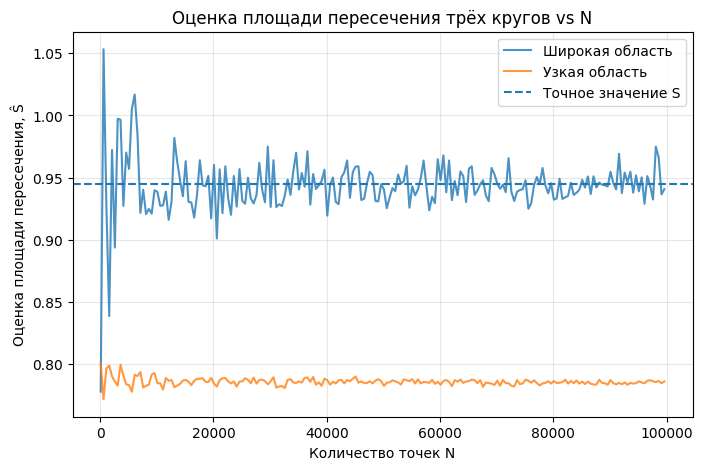

PosixPath('img/area_vs_N.png')

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df["N"], df["S_wide"], label="Широкая область", alpha=0.8)
plt.plot(df["N"], df["S_narrow"], label="Узкая область", alpha=0.8)

# Горизонтальная линия точного значения
plt.axhline(S_exact, linestyle="--", linewidth=1.5, label="Точное значение S")

plt.xlabel("Количество точек N")
plt.ylabel("Оценка площади пересечения, Ŝ")
plt.title("Оценка площади пересечения трёх кругов vs N")
plt.legend()
plt.grid(True, alpha=0.3)

img_area_path = IMG_DIR / "area_vs_N.png"
plt.savefig(img_area_path, dpi=200, bbox_inches="tight")
plt.show()

img_area_path


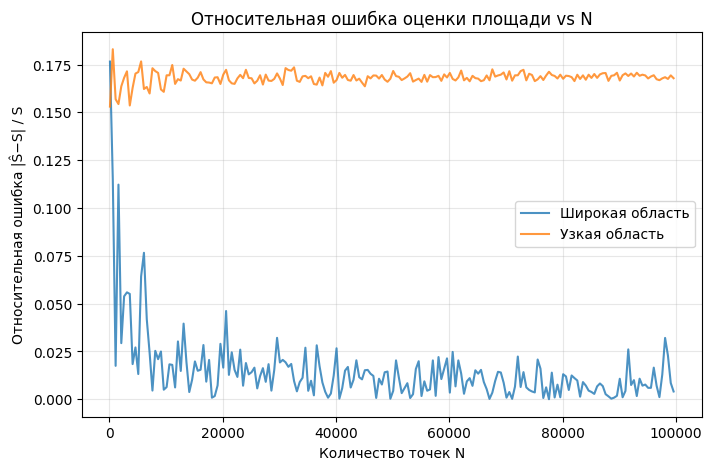

PosixPath('img/rel_error_vs_N.png')

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df["N"], df["rel_err_wide"], label="Широкая область", alpha=0.8)
plt.plot(df["N"], df["rel_err_narrow"], label="Узкая область", alpha=0.8)

plt.xlabel("Количество точек N")
plt.ylabel("Относительная ошибка |Ŝ−S| / S")
plt.title("Относительная ошибка оценки площади vs N")
plt.legend()
plt.grid(True, alpha=0.3)

img_err_path = IMG_DIR / "rel_error_vs_N.png"
plt.savefig(img_err_path, dpi=200, bbox_inches="tight")
plt.show()

img_err_path


## Выводы

В рамках работы была экспериментально исследована оценка площади пересечения трёх окружностей методом Монте-Карло. Для фиксированной конфигурации окружностей из задачи A1 точное значение площади пересечения вычисляется по формуле:

$$
S_{\rm exact} = 0.25 \pi + 1.25 \arcsin(0.8) - 1 \approx 0.9445.
$$

### 1. Поведение оценки площади при увеличении числа точек

Анализ первого типа графиков (оценочная площадь в зависимости от количества точек N) показывает:

- при малых значениях N (от нескольких сотен до первых тысяч) оценки сильно колеблются относительно точного значения;
- при увеличении количества точек амплитуда колебаний постепенно уменьшается;
- начиная примерно с N от 10 000 до 100 000 оценки становятся устойчивыми и находятся в узкой окрестности точного значения.

Таким образом, эксперимент подтверждает ожидаемое свойство метода Монте-Карло: чем больше точек, тем точнее оценка площади.

### 2. Сравнение широкой и узкой прямоугольных областей

В эксперименте использовались две области генерации случайных точек:

- широкая область — прямоугольник, полностью охватывающий все три окружности;
- узкая область — квадрат [1, 2] × [1, 2], плотно ограничивающий реальную область пересечения.

Полученные результаты показывают:

- при одинаковом количестве точек оценки, полученные в узкой области, существенно точнее и ближе к точному значению;
- относительная ошибка в узкой области значительно меньше на всём диапазоне N;
- чтобы достичь аналогичной точности в широкой области, требуется значительно больше случайных точек.

Это объясняется тем, что в широкой области много точек попадают в область, не относящуюся к пересечению, тогда как в узкой области почти каждая точка «работает» на оценку.

### 3. Зависимость ошибки от числа точек и эффективность метода

Графики относительной ошибки показывают закономерность, характерную для метода Монте-Карло:

- ошибка уменьшается приблизительно пропорционально 1 / sqrt(N);
- чтобы уменьшить ошибку в два раза, количество точек необходимо увеличить примерно в четыре раза;
- для получения относительной ошибки порядка одного процента в узкой области достаточно N примерно от 20 000 до 50 000;
- широкая область требует существенно большего числа точек для достижения той же точности.

Таким образом, выбор области моделирования оказывает критическое влияние на эффективность метода.

### 4. Итог

Проведённые эксперименты подтверждают:

- оценки метода Монте-Карло сходятся к точному значению площади при увеличении числа испытаний;
- использование узкой прямоугольной области значительно уменьшает дисперсию и повышает точность;
- относительная ошибка убывает приблизительно как 1 / sqrt(N), что подтверждается экспериментальными данными.

Метод Монте-Карло позволяет эффективно оценивать площади сложных геометрических фигур, однако для повышения точности важно выбирать как можно более компактную область генерации точек.
